<a href="https://colab.research.google.com/github/Adesedasm/Reporte_final/blob/main/Proyecto_Maestria_Pronostico_Poblacion_Penitenciaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Proyecto de Maestría — Pronóstico de Población Penitenciaria de Panamá

**Tema propuesto:**  
**Modelos estadísticos y de aprendizaje automático para el pronóstico a 30 días de la población penitenciaria por centro, Panamá 2024–2026.**

## Diseño analítico

El proyecto se divide en cuatro bloques:

1. **Calidad y preparación de datos**
2. **Análisis descriptivo temporal:** día, mes, trimestre y año
3. **Contraste de hipótesis**
4. **Pronóstico y comparación de modelos:** media móvil, regresión, SARIMA/SARIMAX y XGBoost

### Variable objetivo

\[
Y_{t+30}=\text{Población penitenciaria del mismo centro 30 días después}
\]

El horizonte de 30 días permite conservar la riqueza de la serie diaria y producir un resultado útil para planificación mensual.

### Hipótesis principales

**Hipótesis general**

- \(H_0\): Las características temporales, operativas y penitenciarias no explican significativamente la población penitenciaria futura.
- \(H_1\): Las características temporales, operativas y penitenciarias explican significativamente la población penitenciaria futura.

**Tendencia**

- \(H_0:\beta_{tendencia}=0\)
- \(H_1:\beta_{tendencia}\neq0\)

**Ingresos**

- \(H_0:\beta_{ingresos}=0\)
- \(H_1:\beta_{ingresos}\neq0\)

**Egresos**

- \(H_0:\beta_{egresos}=0\)
- \(H_1:\beta_{egresos}\neq0\)

> Importante: `Saldo = Ingreso - Egreso`. No deben incluirse simultáneamente `Ingreso`, `Egreso` y `Saldo` en la misma regresión porque el saldo es combinación lineal exacta de las otras dos variables.



## 1. Instalar/importar librerías y cargar el archivo

En Google Colab, suba el archivo **Datos poblacion 2024-2026.xlsx** cuando se solicite.


In [14]:

# En Google Colab, si hace falta:
# !pip -q install xgboost openpyxl statsmodels

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

ARCHIVO = "Datos poblacion 2024-2026.xlsx"

if not os.path.exists(ARCHIVO):
    try:
        from google.colab import files
        uploaded = files.upload()
        ARCHIVO = next(iter(uploaded.keys()))
    except Exception:
        raise FileNotFoundError(
            "Coloque el archivo Excel en la misma carpeta del notebook "
            "o modifique la variable ARCHIVO."
        )

df = pd.read_excel(ARCHIVO)

print("Filas:", len(df))
print("Columnas:", df.shape[1])
display(df.head())


Filas: 18634
Columnas: 12


,Fecha,Provincia,Centro,Capacidad,Camas,PoblacionPenal,SobrePoblacion,IndiceHacinamiento,Ingreso,Egreso,NivelHacinamiento,Archivo
0,2024-01-01,Bocas Del Toro,Cárcel Pública De Deborah,292,292,712,420.0,243.835616,1,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...
1,2024-01-01,Chiriquí,Centro Penitenciario De Chiriquí,950,950,2208,1258.0,232.421053,0,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...
2,2024-01-01,Chiriquí,Centro Femenino Los Algarrobos,80,188,193,113.0,102.659574,0,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...
3,2024-01-01,Veraguas,Cárcel Púiblica De Santiago,150,29,713,563.0,2458.620690,0,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...
4,2024-01-01,Los Santos,Cárcel Pública De Las Tablas,75,133,357,282.0,268.421053,0,0.0,Crítico,ESTADO DE FUERZA Y POBLACIO 01 de Enero 2024...



## 2. Auditoría inicial

En la revisión preliminar del archivo recibido se observaron:

- 19,046 registros de datos.
- Período: 1 de enero de 2024 a 30 de junio de 2026.
- 908 fechas diferentes.
- 9 provincias.
- 25 etiquetas originales de centros.
- 10 combinaciones `Fecha-Centro` duplicadas.
- 442 valores faltantes de capacidad.
- 31 valores faltantes de camas.
- El campo `NivelHacinamiento` requiere revisión antes de utilizarlo como variable analítica.


In [15]:

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

print("Rango temporal:", df["Fecha"].min(), "a", df["Fecha"].max())
print("Fechas distintas:", df["Fecha"].nunique())
print("Provincias:", df["Provincia"].nunique())
print("Centros originales:", df["Centro"].nunique())

auditoria = pd.DataFrame({
    "Variable": df.columns,
    "Faltantes": [df[c].isna().sum() for c in df.columns],
    "Porcentaje_faltante": [df[c].isna().mean()*100 for c in df.columns],
    "Valores_unicos": [df[c].nunique(dropna=True) for c in df.columns]
})
display(auditoria)

duplicados = df[df.duplicated(["Fecha", "Centro"], keep=False)].sort_values(["Fecha", "Centro"])
print("Registros involucrados en duplicidades Fecha-Centro:", len(duplicados))
display(duplicados.head(20))

print("\nFrecuencia de NivelHacinamiento:")
display(df["NivelHacinamiento"].value_counts(dropna=False).to_frame("n"))


Rango temporal: 2024-01-01 00:00:00 a 2026-06-30 00:00:00
Fechas distintas: 908
Provincias: 9
Centros originales: 25


,Variable,Faltantes,Porcentaje_faltante,Valores_unicos
0,Fecha,0,0.000000,908
1,Provincia,0,0.000000,9
2,Centro,0,0.000000,25
3,Capacidad,0,0.000000,26
4,Camas,0,0.000000,33
5,PoblacionPenal,0,0.000000,1958
6,SobrePoblacion,2,0.010733,1857
7,IndiceHacinamiento,12,0.064398,2680
8,Ingreso,0,0.000000,60
9,Egreso,1,0.005367,79


Registros involucrados en duplicidades Fecha-Centro: 20


,Fecha,Provincia,Centro,Capacidad,Camas,PoblacionPenal,SobrePoblacion,IndiceHacinamiento,Ingreso,Egreso,NivelHacinamiento,Archivo
799,2024-02-10,Darién,Cárcel Pública De La Palma,18,18,23,5.0,127.777778,0,0.0,Crítico,ESTADO DE FUERZA Y POPLACION 09 FEBRERO.xlsx
818,2024-02-10,Darién,Cárcel Pública De La Palma,18,18,24,6.0,133.333333,1,0.0,Crítico,ESTADO DE FUERZA Y POPLACION 10 FEBRERO.xlsx
1939,2024-04-07,Bocas Del Toro,Cárcel Pública De Deborah,292,292,773,481.0,264.726027,1,0.0,Crítico,ESTADO DE FUERZA Y POPLACION 07 DE ABRIL 2024....
1958,2024-04-07,Bocas Del Toro,Cárcel Pública De Deborah,292,292,773,481.0,264.726027,0,0.0,Crítico,ESTADO DE FUERZA Y POPLACION 08 DE ABRIL 2024....
4870,2024-09-01,Bocas Del Toro,Cárcel Pública De Deborah,292,292,868,562.0,297.260274,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA 01 DE SEPTIEMBRE ...
4871,2024-09-01,Bocas Del Toro,Cárcel Pública De Deborah,292,292,868,562.0,297.260274,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA 01 DE SEPTIEMBRE ...
8580,2025-03-06,Darién,Cárcel Pública De La Palma,18,7,0,0.0,NaN,0,0.0,critico,POBLACION Y ESTADO DE FUERZA DE 05 MARZO 2025....
8600,2025-03-06,Darién,Cárcel Pública De La Palma,18,18,7,-11.0,38.888889,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA DE 06 MARZO 2025....
8663,2025-03-10,Darién,Cárcel Pública De La Palma,18,18,7,-11.0,38.888889,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA DE 10 MARZO 2025....
8683,2025-03-10,Darién,Cárcel Pública De La Palma,18,18,7,-11.0,38.888889,0,0.0,Crítico,POBLACION Y ESTADO DE FUERZA DE 10 MARZO 2025....



Frecuencia de NivelHacinamiento:


,n
NivelHacinamiento,
Crítico,18476
Sin hacinamiento,136
critico,22



## 3. Limpieza mínima y estandarización

Se corrigen únicamente equivalencias evidentes de escritura. No se fusionan centros diferentes sin validación institucional.

También se recalculan dos indicadores distintos:

\[
OcupacionCapacidad = rac{PoblacionPenal}{Capacidad}	imes100
\]

\[
OcupacionCamas = rac{PoblacionPenal}{Camas}	imes100
\]

Esto evita depender del `IndiceHacinamiento` original, cuya fórmula no es homogénea en todo el período.


In [16]:

alias_centros = {
    "Centro Femenino De Colon": "Centro Femenino De Colón",
    "Centro Femenino De Rehabilitacion La Esmelarda": "Centro Femenino La Esmeralda",
}

df["Centro_original"] = df["Centro"]
df["Centro"] = df["Centro"].replace(alias_centros)

# Mantener el último registro cuando existe más de una fila para la misma fecha-centro.
# Las duplicidades deben conservarse aparte como evidencia de calidad.
df = (
    df.sort_values(["Fecha", "Centro"])
      .drop_duplicates(["Fecha", "Centro"], keep="last")
      .reset_index(drop=True)
)

df["OcupacionCapacidad"] = np.where(
    df["Capacidad"].gt(0),
    df["PoblacionPenal"] / df["Capacidad"] * 100,
    np.nan
)

df["OcupacionCamas"] = np.where(
    df["Camas"].gt(0),
    df["PoblacionPenal"] / df["Camas"] * 100,
    np.nan
)

df["SobreCapacidadCalc"] = np.where(
    df["Capacidad"].notna(),
    df["PoblacionPenal"] - df["Capacidad"],
    np.nan
)

df["EstaSobreCapacidad"] = np.where(
    df["Capacidad"].gt(0),
    (df["PoblacionPenal"] > df["Capacidad"]).astype(int),
    np.nan
)

print("Filas después de deduplicar:", len(df))
print("Centros estandarizados:", df["Centro"].nunique())


Filas después de deduplicar: 18624
Centros estandarizados: 23



## 4. Variables analíticas temporales y operativas


In [17]:

df = df.sort_values(["Centro", "Fecha"]).reset_index(drop=True)

# Variables temporales
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month
df["NombreMes"] = df["Fecha"].dt.month_name()
df["Trimestre"] = df["Fecha"].dt.quarter
df["Semana"] = df["Fecha"].dt.isocalendar().week.astype(int)
df["DiaSemana"] = df["Fecha"].dt.dayofweek
df["DiaAño"] = df["Fecha"].dt.dayofyear
df["Tendencia"] = (df["Fecha"] - df["Fecha"].min()).dt.days

# Variables operativas
df["Saldo"] = df["Ingreso"] - df["Egreso"]

# Rezagos
for lag in [1, 7, 14, 30]:
    df[f"PoblacionLag{lag}"] = df.groupby("Centro")["PoblacionPenal"].shift(lag)

# Medias móviles basadas únicamente en información pasada
for ventana in [7, 14, 30]:
    df[f"MediaMovil{ventana}"] = (
        df.groupby("Centro")["PoblacionPenal"]
          .transform(lambda s: s.shift(1).rolling(ventana, min_periods=max(3, ventana//3)).mean())
    )

# Acumulados operativos recientes
for ventana in [7, 30]:
    df[f"Ingreso_{ventana}d"] = (
        df.groupby("Centro")["Ingreso"]
          .transform(lambda s: s.shift(1).rolling(ventana, min_periods=3).sum())
    )
    df[f"Egreso_{ventana}d"] = (
        df.groupby("Centro")["Egreso"]
          .transform(lambda s: s.shift(1).rolling(ventana, min_periods=3).sum())
    )
    df[f"Saldo_{ventana}d"] = df[f"Ingreso_{ventana}d"] - df[f"Egreso_{ventana}d"]

# Crecimiento reciente
df["Crecimiento7d"] = (
    (df["PoblacionPenal"] - df["PoblacionLag7"]) /
    df["PoblacionLag7"].replace(0, np.nan) * 100
)

display(df.head())


,Fecha,Provincia,Centro,Capacidad,Camas,PoblacionPenal,SobrePoblacion,IndiceHacinamiento,Ingreso,Egreso,...,MediaMovil7,MediaMovil14,MediaMovil30,Ingreso_7d,Egreso_7d,Saldo_7d,Ingreso_30d,Egreso_30d,Saldo_30d,Crecimiento7d
0,2024-01-01,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,11.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,2024-01-05,Panamá,C.D.P. De Punta Coco,12,12,11,-1.0,91.666667,0,0.0,...,11.0,11.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN



## 5. Crear la variable objetivo a 30 días

Se utiliza un **emparejamiento por fecha exacta** en vez de `shift(-30)`. Así, si falta un día en la serie, no se confunde "30 filas" con "30 días".


In [18]:

futuro = df[["Centro", "Fecha", "PoblacionPenal"]].copy()
futuro["Fecha"] = futuro["Fecha"] - pd.Timedelta(days=30)
futuro = futuro.rename(columns={"PoblacionPenal": "Poblacion_30d"})

df_modelo = df.merge(
    futuro,
    on=["Centro", "Fecha"],
    how="left"
)

df_modelo["FechaObjetivo"] = df_modelo["Fecha"] + pd.Timedelta(days=30)

print("Registros con objetivo a 30 días:", df_modelo["Poblacion_30d"].notna().sum())


Registros con objetivo a 30 días: 17815



# BLOQUE A — ANÁLISIS DESCRIPTIVO

Para población, capacidad y camas **no se deben sumar las observaciones diarias del mes**.  
La población es un **stock**: para el resumen mensual/anual se toma el último corte disponible del período.

Ingreso y egreso son **flujos**: estos sí se acumulan dentro del período.


In [19]:

# Último corte por centro y mes
corte_mensual = (
    df.sort_values("Fecha")
      .groupby(["Centro", "Año", "Mes"], as_index=False)
      .tail(1)
)

resumen_mensual_stock = (
    corte_mensual
    .groupby(["Año", "Mes"], as_index=False)
    .agg(
        Poblacion=("PoblacionPenal", "sum"),
        Capacidad=("Capacidad", "sum"),
        Camas=("Camas", "sum")
    )
)

flujos_mensuales = (
    df.groupby(["Año", "Mes"], as_index=False)
      .agg(Ingresos=("Ingreso", "sum"), Egresos=("Egreso", "sum"))
)

resumen_mensual = resumen_mensual_stock.merge(
    flujos_mensuales, on=["Año", "Mes"], how="left"
)

resumen_mensual["OcupacionCapacidad"] = (
    resumen_mensual["Poblacion"] / resumen_mensual["Capacidad"] * 100
)
resumen_mensual["Saldo"] = resumen_mensual["Ingresos"] - resumen_mensual["Egresos"]

display(resumen_mensual.tail(12))


,Año,Mes,Poblacion,Capacidad,Camas,Ingresos,Egresos,OcupacionCapacidad,Saldo
18,2025,7,24445,14700,14682,898,1196.0,166.292517,-298.0
19,2025,8,24512,14700,14682,903,837.0,166.748299,66.0
20,2025,9,24576,14700,14682,860,796.0,167.183673,64.0
21,2025,10,24587,14700,14682,933,926.0,167.258503,7.0
22,2025,11,24860,14700,14682,964,724.0,169.115646,240.0
23,2025,12,24924,14700,14682,992,928.0,169.551020,64.0
24,2026,1,24529,14700,14682,777,1183.0,166.863946,-406.0
25,2026,2,24651,14700,14682,667,540.0,167.693878,127.0
26,2026,3,24727,14700,14682,993,917.0,168.210884,76.0
27,2026,4,24831,14700,14682,845,763.0,168.918367,82.0


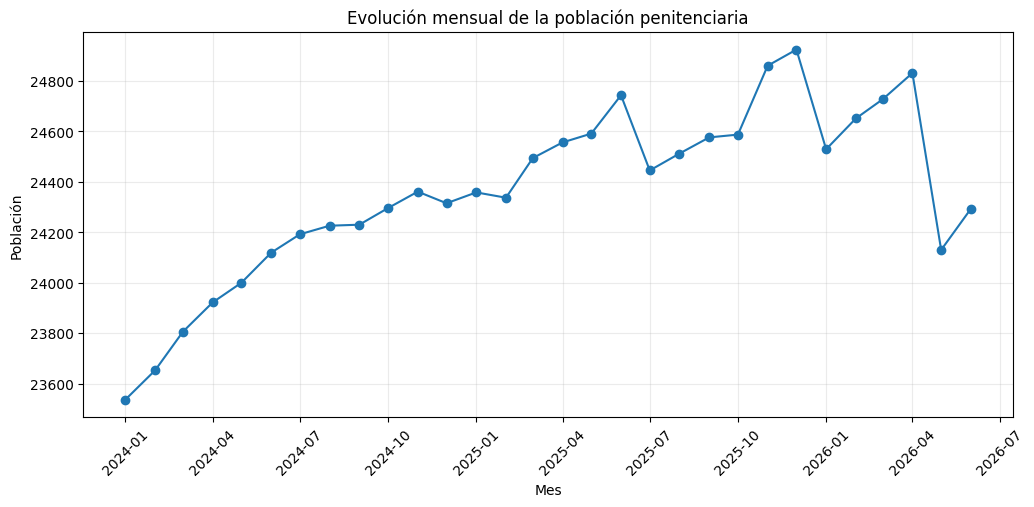

In [20]:

# Evolución mensual de la población
resumen_mensual["Periodo"] = pd.to_datetime(
    resumen_mensual["Año"].astype(str) + "-" +
    resumen_mensual["Mes"].astype(str).str.zfill(2) + "-01"
)

plt.figure(figsize=(12, 5))
plt.plot(resumen_mensual["Periodo"], resumen_mensual["Poblacion"], marker="o")
plt.title("Evolución mensual de la población penitenciaria")
plt.xlabel("Mes")
plt.ylabel("Población")
plt.grid(alpha=.25)
plt.xticks(rotation=45)
plt.show()


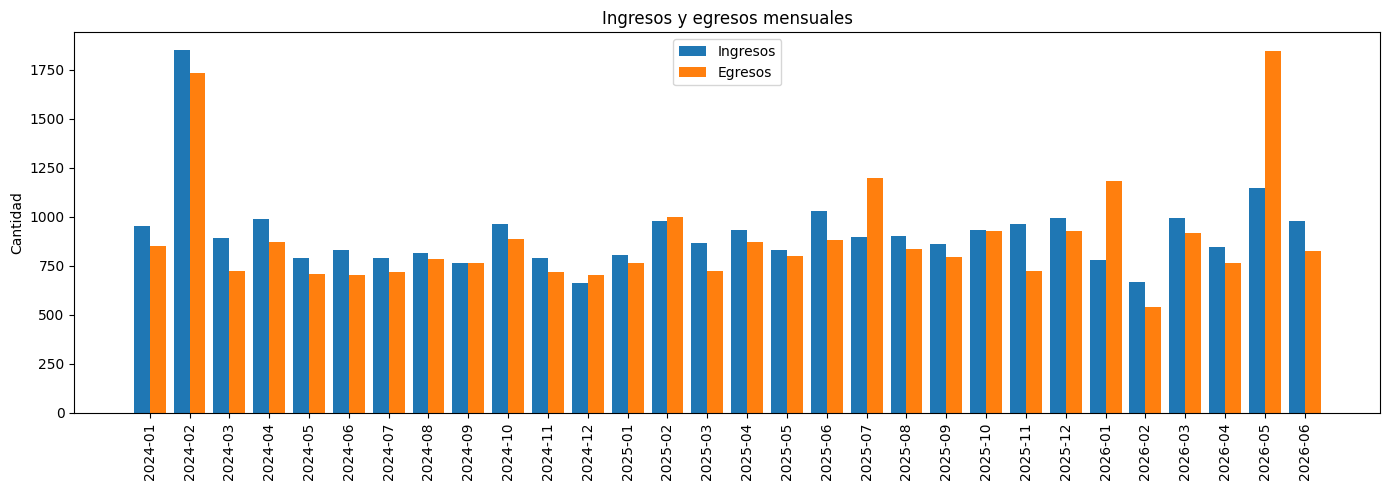

In [21]:

# Ingresos y egresos mensuales
x = np.arange(len(resumen_mensual))
w = 0.4

plt.figure(figsize=(14, 5))
plt.bar(x-w/2, resumen_mensual["Ingresos"], width=w, label="Ingresos")
plt.bar(x+w/2, resumen_mensual["Egresos"], width=w, label="Egresos")
plt.xticks(
    x,
    resumen_mensual["Periodo"].dt.strftime("%Y-%m"),
    rotation=90
)
plt.ylabel("Cantidad")
plt.title("Ingresos y egresos mensuales")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:

# Cierre/último corte por año
cierre_anual = (
    df.sort_values("Fecha")
      .groupby(["Centro", "Año"], as_index=False)
      .tail(1)
      .groupby("Año", as_index=False)
      .agg(
          FechaCorte=("Fecha", "max"),
          Poblacion=("PoblacionPenal", "sum"),
          Capacidad=("Capacidad", "sum"),
          Camas=("Camas", "sum")
      )
)

cierre_anual["SobreCapacidad"] = cierre_anual["Poblacion"] - cierre_anual["Capacidad"]
cierre_anual["OcupacionCapacidad"] = cierre_anual["Poblacion"] / cierre_anual["Capacidad"] * 100
cierre_anual["OcupacionCamas"] = cierre_anual["Poblacion"] / cierre_anual["Camas"] * 100

display(cierre_anual)


,Año,FechaCorte,Poblacion,Capacidad,Camas,SobreCapacidad,OcupacionCapacidad,OcupacionCamas
0,2024,2024-12-31,24315,14496,14647,9819,167.735927,166.006691
1,2025,2025-12-30,24924,14700,14682,10224,169.551020,169.758888
2,2026,2026-06-30,24293,15145,15090,9148,160.402773,160.987409


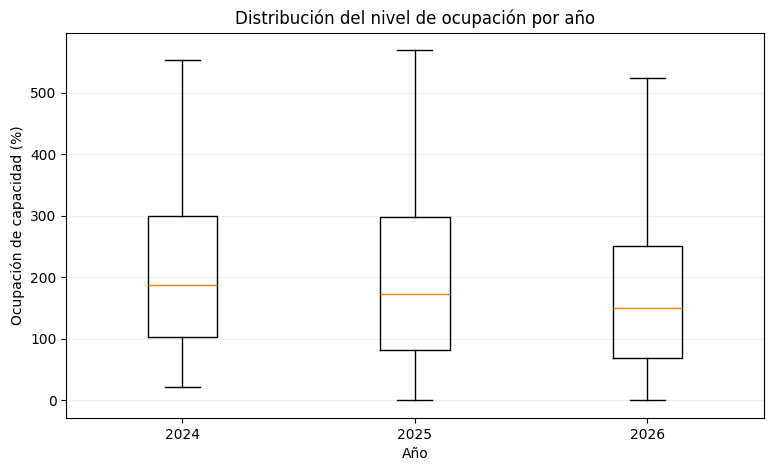

In [23]:

# Boxplot: ocupación de capacidad según año
años = sorted(df["Año"].dropna().unique())
datos = [df.loc[df["Año"] == a, "OcupacionCapacidad"].dropna() for a in años]

plt.figure(figsize=(9, 5))
plt.boxplot(datos, labels=años, showfliers=False)
plt.xlabel("Año")
plt.ylabel("Ocupación de capacidad (%)")
plt.title("Distribución del nivel de ocupación por año")
plt.grid(axis="y", alpha=.2)
plt.show()


In [24]:

# Centros con mayor sobrecapacidad en el último corte disponible
fecha_final = df["Fecha"].max()
ultimo = df[df["Fecha"] == fecha_final].copy()
ultimo = ultimo.sort_values("SobreCapacidadCalc", ascending=False)

display(
    ultimo[
        ["Provincia", "Centro", "PoblacionPenal", "Capacidad",
         "Camas", "SobreCapacidadCalc", "OcupacionCapacidad"]
    ].head(15)
)


,Provincia,Centro,PoblacionPenal,Capacidad,Camas,SobreCapacidadCalc,OcupacionCapacidad
9081,Panamá,Centro Penitenciario La Joya,4900,1568,1568,3332.0,312.500000
9988,Panamá,Centro Penitenciario La Joyita,4714,2837,2836,1877.0,166.161438
8174,Chiriquí,Centro Penitenciario De Chiriquí,2230,950,950,1280.0,234.736842
11802,Colón,Centro Penitenciario Nueva Esperanza,2520,1322,1322,1198.0,190.620272
14097,Bocas Del Toro,Cárcel Pública De Deborah,1020,292,292,728.0,349.315068
17702,Veraguas,Cárcel Púiblica De Santiago,629,150,29,479.0,419.333333
16795,Coclé,Cárcel Pública De Penonomé,673,200,198,473.0,336.500000
15888,Los Santos,Cárcel Pública De Las Tablas,374,80,133,294.0,467.500000
10895,Panamá,Centro Penitenciario La Nueva Joya,5641,5504,5504,137.0,102.489099
1796,Panamá,Centro De Detención De Tinajitas,393,280,396,113.0,140.357143



# BLOQUE B — CONTRASTE DE HIPÓTESIS

Se utiliza una regresión explicativa con efectos fijos de centro y mes.  
Para reducir el problema de dependencia entre observaciones del mismo centro, se calculan **errores estándar agrupados por centro**.

Modelo conceptual:

\[
Poblacion_{t+30} =
eta_0 +
eta_1 Poblacion_t +
eta_2 Ingresos_{30d} +
eta_3 Egresos_{30d} +
eta_4 Capacidad +
eta_5 Camas +
eta_6 Tendencia +
EfectoCentro +
EfectoMes +
\epsilon
\]

Los valores p de `Ingreso_30d`, `Egreso_30d` y `Tendencia` permiten contrastar las hipótesis específicas.


In [25]:

vars_h = [
    "Poblacion_30d", "PoblacionPenal", "Ingreso_30d", "Egreso_30d",
    "Capacidad", "Camas", "Tendencia", "Mes", "Centro"
]

datos_h = df_modelo[vars_h].dropna().copy()

formula = (
    "Poblacion_30d ~ PoblacionPenal + Ingreso_30d + Egreso_30d + "
    "Capacidad + Camas + Tendencia + C(Mes) + C(Centro)"
)

modelo_hipotesis = smf.ols(formula, data=datos_h).fit(
    cov_type="cluster",
    cov_kwds={"groups": datos_h["Centro"]}
)

print(modelo_hipotesis.summary())


                            OLS Regression Results                            
Dep. Variable:          Poblacion_30d   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.785e+04
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           7.52e-42
Time:                        01:48:20   Log-Likelihood:            -1.0351e+05
No. Observations:               17749   AIC:                         2.071e+05
Df Residuals:                   17710   BIC:                         2.074e+05
Df Model:                          38                                         
Covariance Type:              cluster                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------


### Interpretación de las hipótesis

- **Hipótesis general:** revisar el valor p de la prueba F global.
- **Tendencia:** revisar `Tendencia`.
- **Ingresos:** revisar `Ingreso_30d`.
- **Egresos:** revisar `Egreso_30d`.

Si \(p<0.05\), se rechaza \(H_0\) para el efecto evaluado.

> La significancia estadística no implica por sí sola una magnitud importante. Siempre deben revisarse el signo y tamaño del coeficiente y los intervalos de confianza.



# BLOQUE C — DIAGNÓSTICO DE RESIDUALES DE LA REGRESIÓN


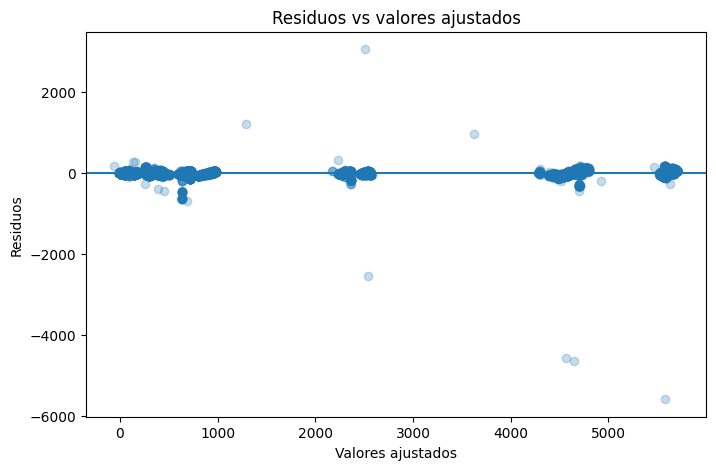

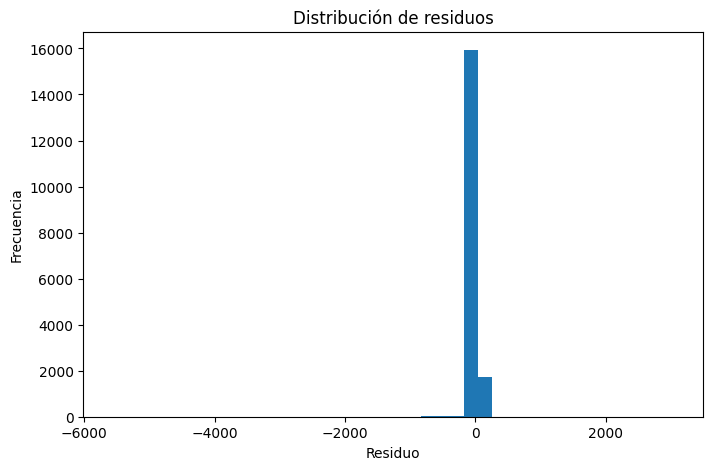

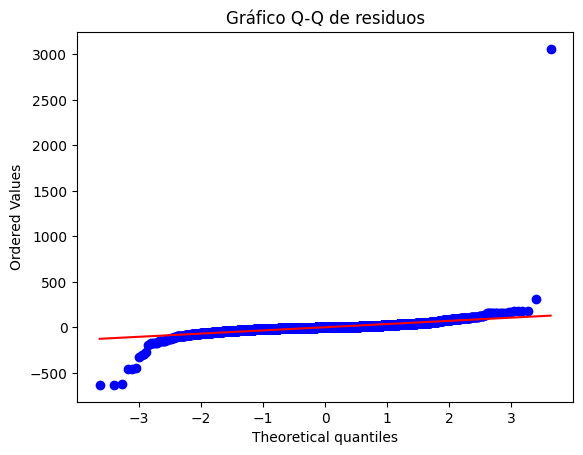

Durbin-Watson: 1.560529220536599
Breusch-Pagan:
{'LM': np.float64(316.53141888609315), 'p_LM': np.float64(1.2610781644025474e-45), 'F': np.float64(8.462387301194017), 'p_F': np.float64(4.199290106220265e-46)}


In [26]:

residuos = modelo_hipotesis.resid
ajustados = modelo_hipotesis.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(ajustados, residuos, alpha=.25)
plt.axhline(0)
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=40)
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

stats.probplot(residuos.sample(min(5000, len(residuos)), random_state=123), dist="norm", plot=plt)
plt.title("Gráfico Q-Q de residuos")
plt.show()

print("Durbin-Watson:", durbin_watson(residuos))

bp = het_breuschpagan(residuos, modelo_hipotesis.model.exog)
print("Breusch-Pagan:")
print({
    "LM": bp[0],
    "p_LM": bp[1],
    "F": bp[2],
    "p_F": bp[3]
})



# BLOQUE D — PREPARACIÓN PARA PRONÓSTICO

Se utiliza una separación estrictamente temporal.

- **Entrenamiento:** objetivos conocidos hasta el 31 de diciembre de 2025.
- **Prueba:** orígenes de pronóstico desde el 1 de enero de 2026.
- No se usa división aleatoria (`train_test_split`), porque produciría fuga temporal.


In [27]:

features_num = [
    "PoblacionPenal",
    "PoblacionLag1",
    "PoblacionLag7",
    "PoblacionLag30",
    "MediaMovil7",
    "MediaMovil30",
    "Ingreso_7d",
    "Egreso_7d",
    "Ingreso_30d",
    "Egreso_30d",
    "Capacidad",
    "Camas",
    "Tendencia",
    "Mes",
    "Trimestre",
    "DiaSemana"
]

features_cat = ["Centro", "Provincia"]

columnas = (
    features_num + features_cat +
    ["Fecha", "FechaObjetivo", "Poblacion_30d"]
)

model_data = df_modelo[columnas].dropna().copy()

train = model_data[model_data["FechaObjetivo"] <= "2025-12-31"].copy()
test = model_data[
    (model_data["Fecha"] >= "2026-01-01") &
    (model_data["FechaObjetivo"] <= df["Fecha"].max())
].copy()

X_train = train[features_num + features_cat]
y_train = train["Poblacion_30d"]

X_test = test[features_num + features_cat]
y_test = test["Poblacion_30d"]

print("Entrenamiento:", len(train))
print("Prueba:", len(test))
print("Centros en prueba:", test["Centro"].nunique())


Entrenamiento: 13557
Prueba: 3013
Centros en prueba: 21


In [28]:

def metricas(nombre, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs(err[mask] / y_true[mask])) * 100 if mask.any() else np.nan
    wape = np.sum(np.abs(err)) / np.sum(np.abs(y_true)) * 100 if np.sum(np.abs(y_true)) else np.nan

    return {
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "WAPE_%": wape,
        "R2": r2
    }

resultados = []



## Modelo 1 — Media móvil de 30 días

Se utiliza como modelo de referencia. Un modelo más complejo debería superar razonablemente esta línea base.


In [29]:

pred_ma = test["MediaMovil30"].values
resultados.append(metricas("Media móvil 30d", y_test, pred_ma))



## Modelo 2 — Regresión lineal predictiva


In [30]:

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
    ]
)

modelo_reg = Pipeline([
    ("prep", preprocesamiento),
    ("modelo", LinearRegression())
])

modelo_reg.fit(X_train, y_train)
pred_reg = modelo_reg.predict(X_test)

resultados.append(metricas("Regresión", y_test, pred_reg))



## Modelo 3 — XGBoost


In [31]:

prep_xgb = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
    ]
)

modelo_xgb = Pipeline([
    ("prep", prep_xgb),
    ("modelo", XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=123,
        n_jobs=-1
    ))
])

modelo_xgb.fit(X_train, y_train)
pred_xgb = modelo_xgb.predict(X_test)

resultados.append(metricas("XGBoost", y_test, pred_xgb))



## Modelo opcional — Random Forest

Puede incluirse como quinto modelo o utilizarse en lugar de XGBoost si el profesor solicita específicamente un ensamble de árboles.


In [32]:

prep_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
    ]
)

modelo_rf = Pipeline([
    ("prep", prep_rf),
    ("modelo", RandomForestRegressor(
        n_estimators=350,
        max_depth=18,
        min_samples_leaf=2,
        random_state=123,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

resultados.append(metricas("Random Forest", y_test, pred_rf))



# BLOQUE E — SARIMA/SARIMAX

La base diaria permite trabajar con una estacionalidad semanal \(s=7\), lo que es mucho más defendible que aplicar un SARIMA mensual con únicamente 30 meses.

Modelo inicial:

\[
SARIMA(1,1,1)(1,0,0)_7
\]

Para comparar AIC se prueban varias especificaciones **dentro de la familia SARIMA**.  
AIC **no debe utilizarse para decidir entre SARIMA, XGBoost, Random Forest y media móvil**.


In [33]:

# Ejemplo de selección por AIC para un centro
CENTRO_EJEMPLO = "Centro Penitenciario La Joya"

serie = (
    df[df["Centro"] == CENTRO_EJEMPLO]
    .set_index("Fecha")["PoblacionPenal"]
    .asfreq("D")
    .interpolate(limit_direction="both")
)

serie_train = serie.loc[:"2025-12-31"]

candidatos = [
    ((1,1,0), (0,0,0,0)),
    ((1,1,1), (0,0,0,0)),
    ((2,1,1), (0,0,0,0)),
    ((1,1,1), (1,0,0,7)),
    ((2,1,1), (1,0,0,7)),
]

tabla_aic = []

for order, seasonal in candidatos:
    try:
        fit = SARIMAX(
            serie_train,
            order=order,
            seasonal_order=seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        tabla_aic.append({
            "order": str(order),
            "seasonal_order": str(seasonal),
            "AIC": fit.aic,
            "BIC": fit.bic
        })
    except Exception as e:
        print("No convergió:", order, seasonal, e)

tabla_aic = pd.DataFrame(tabla_aic).sort_values("AIC")
display(tabla_aic)


,order,seasonal_order,AIC,BIC
4,"(2, 1, 1)","(1, 0, 0, 7)",9556.257429,9579.160625
3,"(1, 1, 1)","(1, 0, 0, 7)",9566.511656,9584.839757
1,"(1, 1, 1)","(0, 0, 0, 0)",9638.016038,9651.786941
2,"(2, 1, 1)","(0, 0, 0, 0)",9640.009615,9658.370819
0,"(1, 1, 0)","(0, 0, 0, 0)",9890.659505,9899.842853



## Evaluación SARIMA a 30 días con orígenes mensuales

Para evitar cientos de reajustes diarios, se utilizan cinco orígenes de pronóstico en 2026.  
Cada pronóstico se realiza utilizando solamente información conocida hasta el origen.


In [34]:

origenes = pd.to_datetime([
    "2026-01-31",
    "2026-02-28",
    "2026-03-31",
    "2026-04-30",
    "2026-05-31"
])

centros_sarima = [
    c for c, n in df.groupby("Centro").size().items()
    if n >= 700
]

pred_sarima = []

for centro in centros_sarima:
    serie_full = (
        df[df["Centro"] == centro]
        .set_index("Fecha")["PoblacionPenal"]
        .sort_index()
        .asfreq("D")
        .interpolate(limit_direction="both")
    )

    for origen in origenes:
        fecha_obj = origen + pd.Timedelta(days=30)

        if origen not in serie_full.index or fecha_obj not in serie_full.index:
            continue

        y_hist = serie_full.loc[:origen]

        if len(y_hist) < 200:
            continue

        try:
            fit = SARIMAX(
                y_hist,
                order=(1,1,1),
                seasonal_order=(1,0,0,7),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            forecast = fit.forecast(30)

            pred_sarima.append({
                "Centro": centro,
                "Fecha": origen,
                "FechaObjetivo": fecha_obj,
                "Real": float(serie_full.loc[fecha_obj]),
                "Pred_SARIMA": float(forecast.iloc[-1]),
                "AIC": fit.aic
            })

        except Exception as e:
            print("Error SARIMA:", centro, origen.date(), e)

sarima_eval = pd.DataFrame(pred_sarima)
display(sarima_eval.head())

if len(sarima_eval):
    resultados.append(
        metricas(
            "SARIMA",
            sarima_eval["Real"],
            sarima_eval["Pred_SARIMA"]
        )
    )


,Centro,Fecha,FechaObjetivo,Real,Pred_SARIMA,AIC
0,C.D.P. De Punta Coco,2026-01-31,2026-03-02,6.0,6.000005,331.599044
1,C.D.P. De Punta Coco,2026-02-28,2026-03-30,6.0,6.000000,315.106771
2,C.D.P. De Punta Coco,2026-03-31,2026-04-30,6.0,6.000000,295.677731
3,C.D.P. De Punta Coco,2026-04-30,2026-05-30,10.0,6.000000,275.747836
4,Centro De Detención De Tinajitas,2026-01-31,2026-03-02,402.0,402.707299,6828.384742



# BLOQUE F — COMPARACIÓN DE MODELOS

Para la selección general use **MAE, RMSE, MAPE/WAPE y \(R^2\)**.

- Menor MAE: menor error absoluto promedio.
- Menor RMSE: castiga más los errores grandes.
- Menor MAPE/WAPE: menor error relativo.
- Mayor \(R^2\): mayor proporción de variabilidad explicada.

**AIC/BIC:** exclusivamente para comparar modelos probabilísticos comparables, por ejemplo distintas especificaciones ARIMA/SARIMA.


In [35]:

tabla_modelos = pd.DataFrame(resultados).sort_values("RMSE")
display(tabla_modelos)

if len(tabla_modelos):
    mejor = tabla_modelos.iloc[0]
    print(
        f"Según RMSE, el mejor modelo en esta evaluación es "
        f"{mejor['Modelo']} con RMSE={mejor['RMSE']:.2f}."
    )


,Modelo,MAE,RMSE,MAPE_%,WAPE_%,R2
0,Media móvil 30d,21.950415,57.975729,14.060092,1.854797,0.998901
1,Regresión,22.855830,59.175584,25.265052,1.931304,0.998855
3,Random Forest,27.422919,63.165850,21.226601,2.317220,0.998695
4,SARIMA,23.966480,72.697162,46.837506,1.940975,0.998331
2,XGBoost,31.386909,75.135829,26.609538,2.652175,0.998154


Según RMSE, el mejor modelo en esta evaluación es Media móvil 30d con RMSE=57.98.



# BLOQUE G — RESIDUALES DE LOS MODELOS PREDICTIVOS


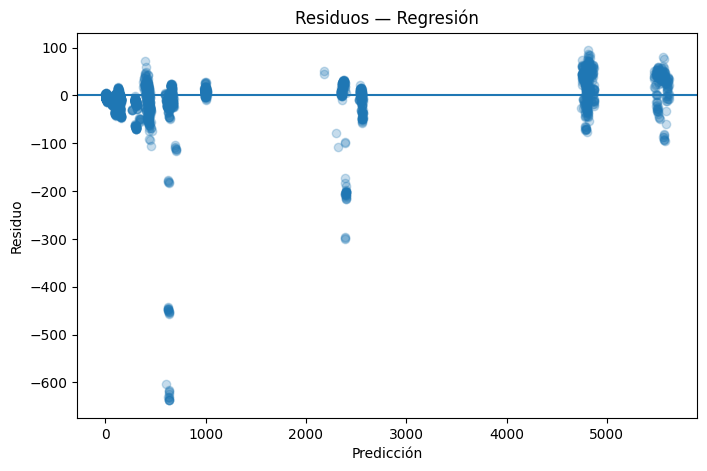

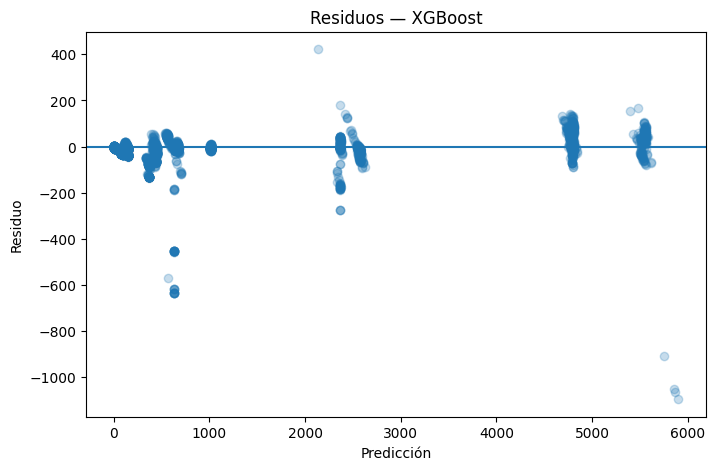

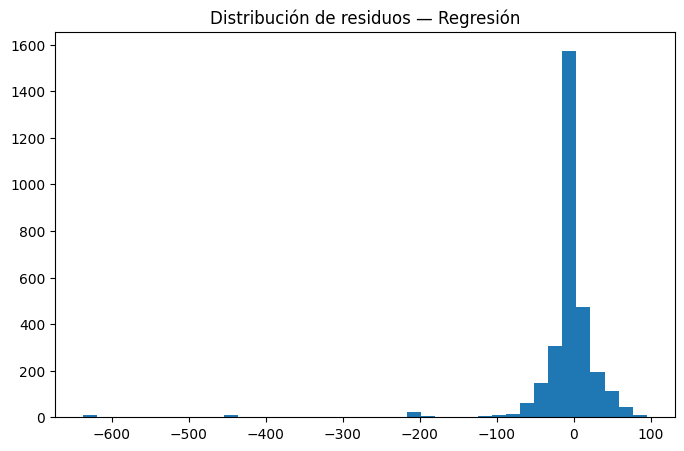

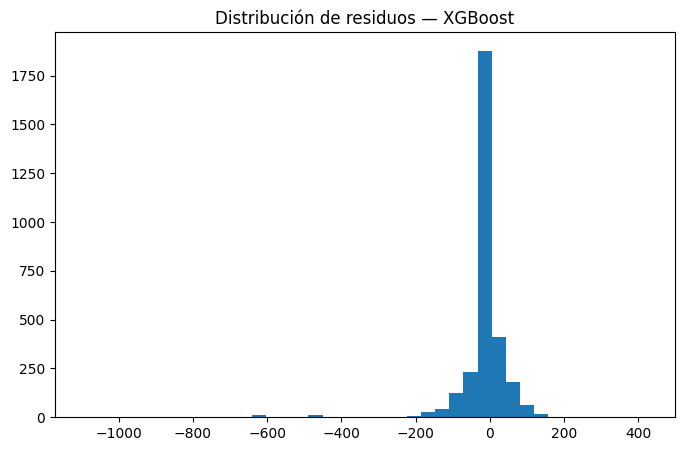

In [36]:

# Regresión
res_reg = y_test.values - pred_reg

plt.figure(figsize=(8,5))
plt.scatter(pred_reg, res_reg, alpha=.25)
plt.axhline(0)
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos — Regresión")
plt.show()

# XGBoost
res_xgb = y_test.values - pred_xgb

plt.figure(figsize=(8,5))
plt.scatter(pred_xgb, res_xgb, alpha=.25)
plt.axhline(0)
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos — XGBoost")
plt.show()

# Histograma comparativo por separado
plt.figure(figsize=(8,5))
plt.hist(res_reg, bins=40)
plt.title("Distribución de residuos — Regresión")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(res_xgb, bins=40)
plt.title("Distribución de residuos — XGBoost")
plt.show()


                                     SARIMAX Results                                      
Dep. Variable:                     PoblacionPenal   No. Observations:                  731
Model:             SARIMAX(2, 1, 1)x(1, 0, [], 7)   Log Likelihood               -4773.129
Date:                            Sat, 19 Sep 2026   AIC                           9556.257
Time:                                    01:49:42   BIC                           9579.161
Sample:                                01-01-2024   HQIC                          9565.099
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0046      0.025     -0.181      0.856      -0.054       0.045
ar.L2         -0.0036      0.026   

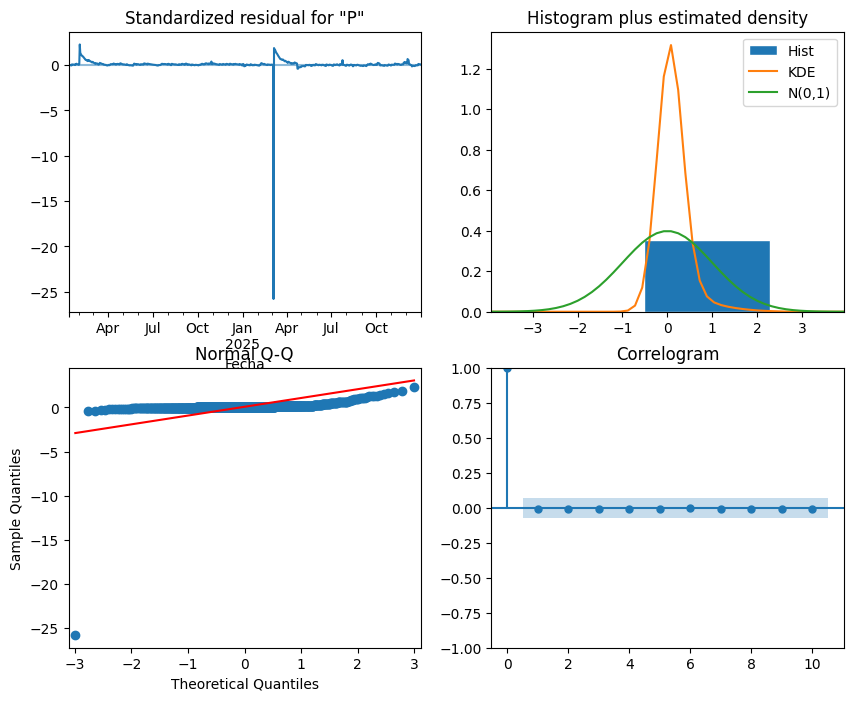

     lb_stat  lb_pvalue
7   0.164765   0.999987
14  0.294207   1.000000
21  0.373774   1.000000


In [37]:

# Diagnóstico del SARIMA para el centro de ejemplo usando la mejor especificación por AIC
if len(tabla_aic):
    mejor_order = eval(tabla_aic.iloc[0]["order"])
    mejor_seasonal = eval(tabla_aic.iloc[0]["seasonal_order"])

    fit_final = SARIMAX(
        serie_train,
        order=mejor_order,
        seasonal_order=mejor_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    print(fit_final.summary())
    fit_final.plot_diagnostics(figsize=(10,8))
    plt.show()

    residuos_sarima = fit_final.resid.dropna()

    print(
        acorr_ljungbox(
            residuos_sarima,
            lags=[7, 14, 21],
            return_df=True
        )
    )



# BLOQUE H — Importancia de variables en XGBoost


,Variable,Importancia
10,num__Capacidad,0.485990
44,cat__Provincia_Panamá,0.322261
11,num__Camas,0.103203
5,num__MediaMovil30,0.061259
4,num__MediaMovil7,0.021001
0,num__PoblacionPenal,0.001627
1,num__PoblacionLag1,0.001508
31,cat__Centro_Cárcel Pública De Deborah,0.000656
24,cat__Centro_Centro Penitenciario De Chiriquí,0.000646
22,cat__Centro_Centro Femenino Los Algarrobos,0.000554


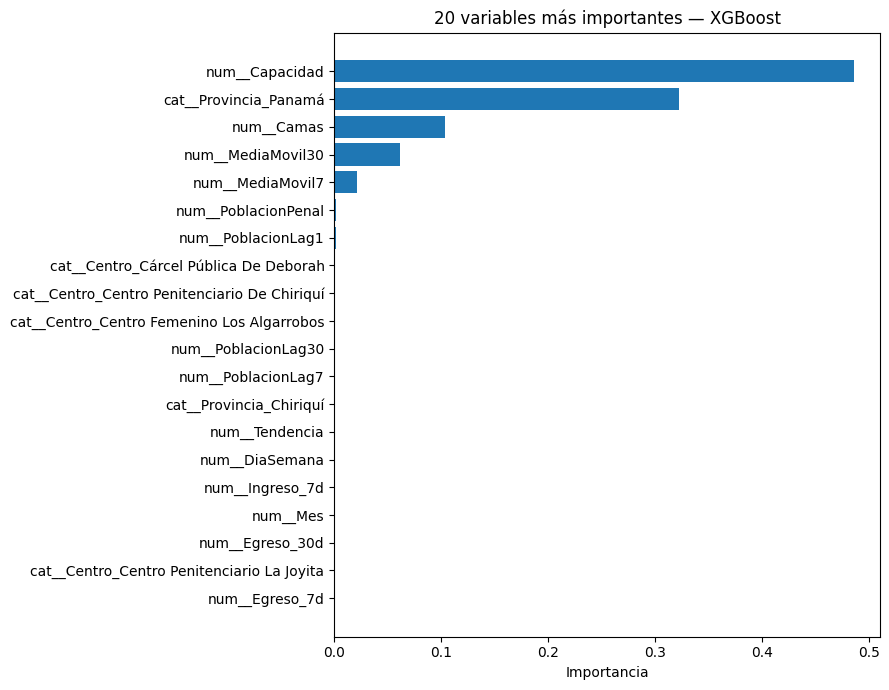

In [38]:

# Recuperar nombres de variables después del preprocesamiento
prep = modelo_xgb.named_steps["prep"]
modelo = modelo_xgb.named_steps["modelo"]

nombres = prep.get_feature_names_out()
importancias = modelo.feature_importances_

imp = (
    pd.DataFrame({"Variable": nombres, "Importancia": importancias})
      .sort_values("Importancia", ascending=False)
      .head(20)
)

display(imp)

plt.figure(figsize=(9,7))
plt.barh(imp["Variable"][::-1], imp["Importancia"][::-1])
plt.title("20 variables más importantes — XGBoost")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()



# Conclusión metodológica esperada

El proyecto debe responder tres preguntas diferentes:

1. **¿Qué ha ocurrido?**  
   Análisis descriptivo por mes, trimestre, año, provincia y centro.

2. **¿Qué variables explican la población futura?**  
   Regresión con contraste de hipótesis y errores estándar agrupados por centro.

3. **¿Qué modelo pronostica mejor?**  
   Comparación fuera de muestra de media móvil, regresión, SARIMA y XGBoost mediante MAE, RMSE, MAPE/WAPE y \(R^2\).

La elección final debe basarse en desempeño fuera de muestra, interpretabilidad y coherencia de los residuales; no únicamente en \(R^2\) o AIC.
